In [1]:
import json, math, subprocess
from pathlib import Path

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,
    'figure.dpi': 100,
})
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

DATA_ROOT = Path('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/data/lerobot/v1.0')
VIEWS     = ['left', 'center', 'right']
VIEW_KEYS = [f'observation.images.{v}_camera' for v in VIEWS]

RESIZE_H, RESIZE_W = 256, 288

print('DATA_ROOT:', DATA_ROOT)

DATA_ROOT: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/data/lerobot/v1.0


## Section 1 — 데이터 파싱 (Parquet + meta)

### 무엇을 보는가
`data/chunk-*/file-*.parquet` 을 읽어 **state / action / plug_to_port / scenario_params** 를 열로 펼친  
단일 DataFrame `steps_df` 를 만듭니다. 행 1개 = 프레임 1개이며, 이후 모든 분석의 입력입니다.

### 어떻게 판단하는가
- `Total frames`: `info.json` 의 `total_frames` 와 일치하는지 확인
- `episode_index` 분포: 에피소드별 프레임 수가 균등한지 확인

In [2]:
# ── 1-1: meta/info.json 로드 ─────────────────────────────────────────────────
with open(DATA_ROOT / 'meta/info.json') as f:
    info = json.load(f)
print(json.dumps(info, indent=2))

{
  "codebase_version": "v3.0",
  "robot_type": null,
  "total_episodes": 70,
  "total_frames": 12299,
  "total_tasks": 2,
  "chunks_size": 1000,
  "data_files_size_in_mb": 100,
  "video_files_size_in_mb": 200,
  "fps": 10,
  "splits": {
    "train": "0:70"
  },
  "data_path": "data/chunk-{chunk_index:03d}/file-{file_index:03d}.parquet",
  "video_path": "videos/{video_key}/chunk-{chunk_index:03d}/file-{file_index:03d}.mp4",
  "features": {
    "observation.state": {
      "dtype": "float32",
      "shape": [
        35
      ],
      "names": [
        "tcp_pose.position.x",
        "tcp_pose.position.y",
        "tcp_pose.position.z",
        "tcp_pose.orientation.x",
        "tcp_pose.orientation.y",
        "tcp_pose.orientation.z",
        "tcp_pose.orientation.w",
        "tcp_velocity.linear.x",
        "tcp_velocity.linear.y",
        "tcp_velocity.linear.z",
        "tcp_velocity.angular.x",
        "tcp_velocity.angular.y",
        "tcp_velocity.angular.z",
        "tcp_error.

In [3]:
# ── 1-2: Parquet 로드 및 컬럼 전개 ───────────────────────────────────────────
STATE_NAMES = [
    'tcp_pose.position.x', 'tcp_pose.position.y', 'tcp_pose.position.z',
    'tcp_pose.orientation.x', 'tcp_pose.orientation.y',
    'tcp_pose.orientation.z', 'tcp_pose.orientation.w',
    'tcp_velocity.linear.x', 'tcp_velocity.linear.y', 'tcp_velocity.linear.z',
    'tcp_velocity.angular.x', 'tcp_velocity.angular.y', 'tcp_velocity.angular.z',
    'tcp_error.x', 'tcp_error.y', 'tcp_error.z',
    'tcp_error.rx', 'tcp_error.ry', 'tcp_error.rz',
    'joint_positions.0', 'joint_positions.1', 'joint_positions.2',
    'joint_positions.3', 'joint_positions.4', 'joint_positions.5', 'joint_positions.6',
    'force.x', 'force.y', 'force.z',
    'torque.x', 'torque.y', 'torque.z',
    'gripper_offset.x', 'gripper_offset.y', 'gripper_offset.z',
]
ACTION_NAMES = [
    'action.position.x', 'action.position.y', 'action.position.z',
    'action.orientation.x', 'action.orientation.y',
    'action.orientation.z', 'action.orientation.w',
]
PLUG_NAMES = [
    'plug_to_port.translation.x', 'plug_to_port.translation.y', 'plug_to_port.translation.z',
    'plug_to_port.rotation.x', 'plug_to_port.rotation.y', 'plug_to_port.rotation.z', 'plug_to_port.rotation.w',
]
SCENARIO_NAMES = [
    'trial_type', 'rail_idx', 'board_x', 'board_y', 'board_yaw',
    'gripper_offset_x', 'gripper_offset_y', 'gripper_offset_z',
    'nic_translation', 'nic_yaw', 'sc_translation',
]

raw_dfs = []
for pq in sorted((DATA_ROOT / 'data').rglob('*.parquet')):
    raw_dfs.append(pd.read_parquet(pq))
raw = pd.concat(raw_dfs, ignore_index=True).sort_values('index').reset_index(drop=True)

s  = pd.DataFrame(np.stack(raw['observation.state'].values),          columns=STATE_NAMES)
a  = pd.DataFrame(np.stack(raw['action'].values),                      columns=ACTION_NAMES)
p  = pd.DataFrame(np.stack(raw['observation.plug_to_port'].values),    columns=PLUG_NAMES)
sc = pd.DataFrame(np.stack(raw['observation.scenario_params'].values), columns=SCENARIO_NAMES)

# insertion_success: v1.0+ format (shape (1,) 배열 or 스칼라)
if 'insertion_success' in raw.columns:
    raw_succ = raw['insertion_success'].apply(
        lambda x: int(x[0]) if hasattr(x, '__len__') else int(x)
    )
else:
    raw_succ = pd.Series([-1] * len(raw), index=raw.index)  # 미지원 버전 fallback

# phase: v1.0+ format (string: approach/descent/insert/stabilize)
if 'phase' in raw.columns:
    raw_phase = raw['phase']
else:
    raw_phase = pd.Series([None] * len(raw), index=raw.index)

steps_df = pd.concat([
    raw[['index', 'episode_index', 'frame_index', 'timestamp', 'task_index']],
    s, a, p, sc,
    raw_succ.rename('insertion_success'),
    raw_phase.rename('phase_label'),
], axis=1)

print(f'Total frames: {len(steps_df):,}  (info.json says {info["total_frames"]})')
print('\nEpisode frame counts:')
print(steps_df['episode_index'].value_counts().sort_index())

Total frames: 12,299  (info.json says 12299)

Episode frame counts:
episode_index
0     168
1     170
2     170
3     173
4     173
     ... 
65    174
66    168
67    174
68    191
69    191
Name: count, Length: 70, dtype: int64


In [5]:
display(steps_df.head(20))

,index,episode_index,frame_index,timestamp,task_index,tcp_pose.position.x,tcp_pose.position.y,tcp_pose.position.z,tcp_pose.orientation.x,tcp_pose.orientation.y,tcp_pose.orientation.z,tcp_pose.orientation.w,tcp_velocity.linear.x,tcp_velocity.linear.y,tcp_velocity.linear.z,tcp_velocity.angular.x,tcp_velocity.angular.y,tcp_velocity.angular.z,tcp_error.x,tcp_error.y,tcp_error.z,tcp_error.rx,tcp_error.ry,tcp_error.rz,joint_positions.0,joint_positions.1,joint_positions.2,joint_positions.3,joint_positions.4,joint_positions.5,joint_positions.6,force.x,force.y,force.z,torque.x,torque.y,torque.z,gripper_offset.x,gripper_offset.y,gripper_offset.z,action.position.x,action.position.y,action.position.z,action.orientation.x,action.orientation.y,action.orientation.z,action.orientation.w,plug_to_port.translation.x,plug_to_port.translation.y,plug_to_port.translation.z,plug_to_port.rotation.x,plug_to_port.rotation.y,plug_to_port.rotation.z,plug_to_port.rotation.w,trial_type,rail_idx,board_x,board_y,board_yaw,gripper_offset_x,gripper_offset_y,gripper_offset_z,nic_translation,nic_yaw,sc_translation,insertion_success,phase_label
0,0,0,0,0.0,0,-0.418207,0.541047,0.258104,-0.519900,0.837269,0.156066,-0.065783,-0.004913,0.038449,-0.007825,-0.020805,0.035029,-0.199276,-0.000390,0.015520,0.000460,-0.005542,0.014809,-0.079458,-0.733844,-1.796878,-1.530758,-1.046561,1.609987,2.873878,0.003541,0.963403,-6.545127,19.649094,0.040553,0.183671,0.089207,-0.001166,0.016601,0.043263,-0.419453,0.568870,0.255911,-0.453269,0.873647,0.163163,-0.068311,0.038599,-0.029518,-0.068056,0.013930,-0.025419,-0.155284,0.987445,0.0,0.0,0.15,-0.2,0.728653,-0.001166,0.016601,0.043263,-0.011009,0.112201,0.038278,0,None
1,1,0,1,0.1,0,-0.419307,0.555814,0.255364,-0.482603,0.858469,0.160008,-0.067250,-0.003886,0.032410,-0.006855,-0.014525,0.030685,-0.163500,-0.000146,0.013056,0.000547,-0.004410,0.012215,-0.065110,-0.744159,-1.821180,-1.511795,-1.031631,1.599270,2.948960,0.003541,1.096279,-7.273237,19.627256,0.035212,0.198637,0.093718,-0.001166,0.016601,0.043263,-0.419743,0.578851,0.253329,-0.427569,0.886015,0.165465,-0.069158,0.028652,-0.017953,-0.064939,0.010223,-0.018040,-0.111099,0.993593,0.0,0.0,0.15,-0.2,0.728653,-0.001166,0.016601,0.043263,-0.011009,0.112201,0.038278,0,None
2,2,0,2,0.2,0,-0.419597,0.560779,0.254449,-0.469127,0.865622,0.161386,-0.067627,-0.000543,0.036942,-0.007973,-0.013266,0.041523,-0.231226,-0.000146,0.018072,-0.001119,-0.006581,0.017140,-0.091173,-0.747290,-1.829221,-1.505436,-1.026747,1.594881,2.976079,0.003541,1.290756,-7.032079,19.817780,0.056886,0.211320,0.018512,-0.001166,0.016601,0.043263,-0.419361,0.582411,0.251840,-0.417787,0.890472,0.166431,-0.069380,0.025777,-0.014900,-0.064118,0.008923,-0.015987,-0.097224,0.995094,0.0,0.0,0.15,-0.2,0.728653,-0.001166,0.016601,0.043263,-0.011009,0.112201,0.038278,0,None
3,3,0,3,0.3,0,-0.419627,0.564515,0.253594,-0.458684,0.870967,0.162519,-0.067928,0.000298,0.037804,-0.009437,-0.014153,0.040887,-0.225952,0.000266,0.017895,-0.001753,-0.006417,0.016768,-0.089223,-0.749755,-1.835020,-1.501457,-1.022354,1.591449,2.996864,0.003541,1.144843,-7.080713,19.888599,0.007177,0.053687,0.096193,-0.001166,0.016601,0.043263,-0.418865,0.585634,0.250145,-0.409267,0.894257,0.167200,-0.069633,0.022888,-0.011903,-0.062988,0.007738,-0.013876,-0.084174,0.996324,0.0,0.0,0.15,-0.2,0.728653,-0.001166,0.016601,0.043263,-0.011009,0.112201,0.038278,0,None
4,4,0,4,0.4,0,-0.419671,0.568140,0.252572,-0.448854,0.875866,0.163499,-0.068236,0.000690,0.036725,-0.011260,-0.014936,0.038487,-0.217487,0.000806,0.017494,-0.002427,-0.006189,0.016209,-0.085931,-0.752211,-1.840930,-1.497580,-1.018080,1.588353,3.016189,0.003541,0.852070,-7.067481,19.380033,0.107622,0.021199,0.075725,-0.001166,0.016601,0.043263,-0.418245,0.588479,0.248351,-0.401899,0.897458,0.167837,-0.069832,0.020041,-0.009116,-0.061695,0.006702,-0.011974,-0.072251,0.997292,0.0,0.0,0.15,-0.2,0.728653,-0.001166,0.016601,0.043263,-0.011009,0.112201,0.038278,0,None
5,5,0,5,0.5,0,-0.419518,0.57333

## Section 1-3 — Phase 레이블

### 무엇을 보는가
`phase` 는 `recording.py` 가 각 프레임에 직접 기록한 레이블입니다.  
v1.0 이전 데이터(phase_label=None)는 `plug_to_port.translation.z` 임계값으로 추론합니다.

| phase | 의미 |
|-------|------|
| approach | 포트로부터 멀리 떨어진 접근 단계 |
| descent | 근접 하강 단계 (3cm 이내) |
| insert | 삽입 진행 단계 |
| stabilize | 삽입 완료 후 안정화 단계 |


[Phase] plug_to_port.translation.z 임계값으로 추론


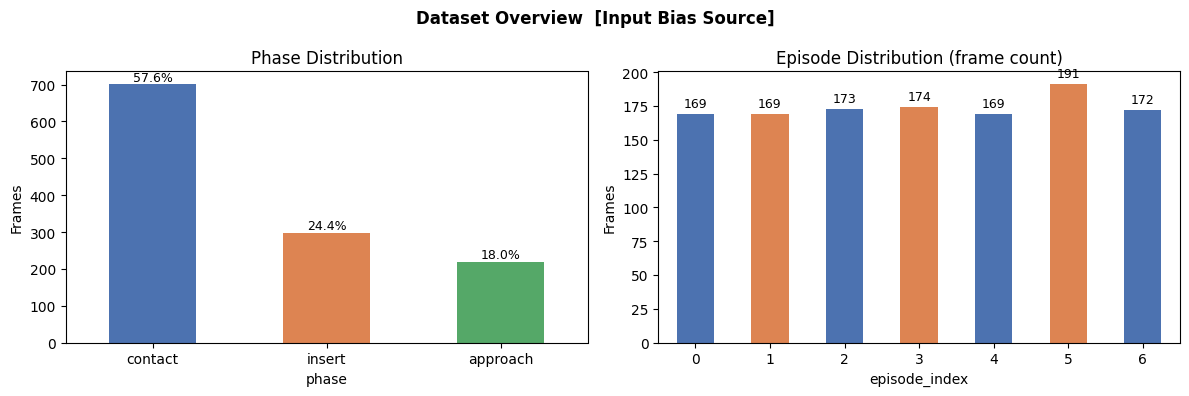

Phase distribution:
  contact   :   701  (57.6%)
  insert    :   297  (24.4%)
  approach  :   219  (18.0%)


In [9]:
# ── 1-3: Phase 레이블 (저장값 우선, 없으면 추론) ─────────────────────────────
def infer_phase(tz):
    if tz < -0.05:  return 'approach'
    if tz < -0.005: return 'insert'
    return 'contact'

if steps_df['phase_label'].notna().all():
    steps_df['phase'] = steps_df['phase_label']
    print('[Phase] 저장된 phase_label 사용')
else:
    steps_df['phase'] = steps_df['plug_to_port.translation.z'].apply(infer_phase)
    print('[Phase] plug_to_port.translation.z 임계값으로 추론')

phase_cnt = steps_df['phase'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

phase_cnt.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868','#C44E52'], rot=0)
for bar, v in zip(axes[0].patches, phase_cnt):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{v/phase_cnt.sum()*100:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Phase Distribution')
axes[0].set_ylabel('Frames')

ep_cnt = steps_df['episode_index'].value_counts().sort_index()
ep_cnt.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'], rot=0)
for bar, v in zip(axes[1].patches, ep_cnt):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{v}', ha='center', fontsize=9)
axes[1].set_title('Episode Distribution (frame count)')
axes[1].set_ylabel('Frames')

plt.suptitle('Dataset Overview  [Input Bias Source]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Phase distribution:')
for ph, c in phase_cnt.items():
    print(f'  {ph:10s}: {c:5d}  ({c/phase_cnt.sum()*100:.1f}%)')


## Section 2-1 — Plug-to-Port XY Error 분포 (Output Space Bias)

### 무엇을 보는가
`plug_to_port.tx` / `plug_to_port.ty` = 플러그 → 포트 방향 XY 오차 (월드 프레임, 미터).  
이 값이 0에 수렴하면 삽입 성공입니다.  
**approach 와 insert 두 위상 모두** 의 오차 분포와 시간적 수렴 경향을 확인합니다.

### 어떻게 판단하는가
- scatter 가 0 중심 대칭 → bias 낮음 / 한쪽 치우침 → 시스템 오프셋 존재
- 에피소드 후반부 error 감소 → 수렴 제어기 정상 동작


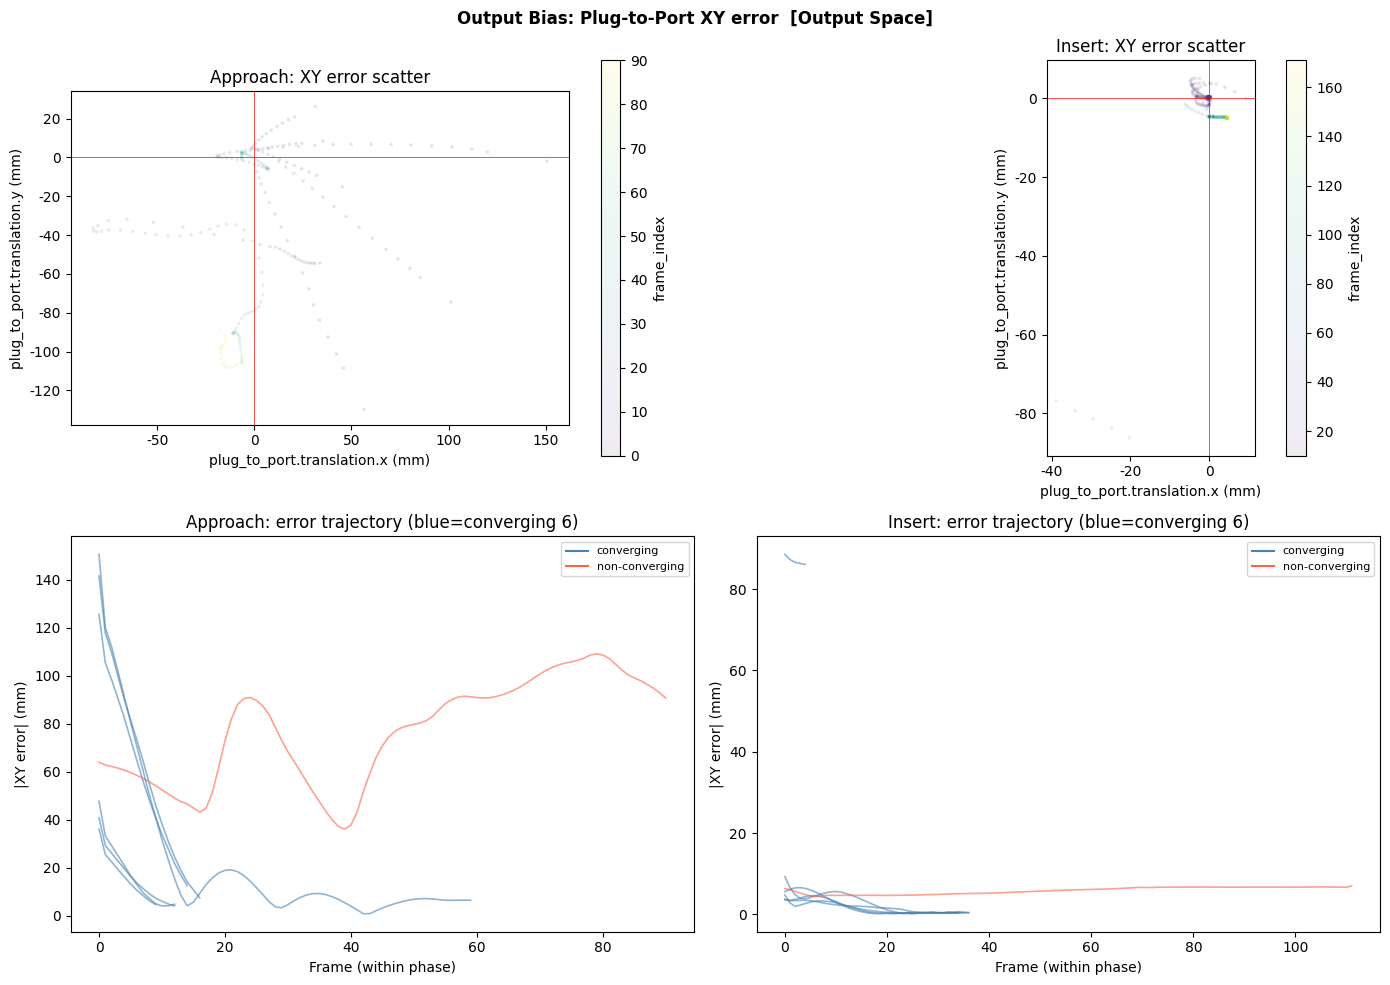

Plug-to-Port XY error stats (insert phase):


,plug_to_port.translation.x,plug_to_port.translation.y
count,297.00000,297.00000
mean,-0.00022,-0.00284
std,0.00478,0.01069
min,-0.03888,-0.08616
25%,-0.00148,-0.00481
50%,-0.00009,-0.00028
75%,0.00208,0.00035
max,0.00927,0.00505



Insert: x_mean=-0.216mm (std=4.781)  y_mean=-2.838mm (std=10.691)  [symmetric]


In [10]:
# ── 2-1: Plug-to-Port XY error scatter + convergence ────────────────────────
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_i, phase in enumerate(['approach', 'insert']):
    sub = steps_df[steps_df['phase'] == phase]

    # scatter
    ax = axes[0, col_i]
    sc_plot = ax.scatter(
        sub['plug_to_port.translation.x']*1000, sub['plug_to_port.translation.y']*1000,
        alpha=0.08, s=3, c=sub['frame_index'], cmap='viridis'
    )
    ax.axhline(0, color='red', lw=0.5); ax.axvline(0, color='red', lw=0.5)
    ax.set_xlabel('plug_to_port.translation.x (mm)'); ax.set_ylabel('plug_to_port.translation.y (mm)')
    ax.set_title(f'{phase.capitalize()}: XY error scatter')
    ax.set_aspect('equal')
    plt.colorbar(sc_plot, ax=ax, label='frame_index')

    # convergence trajectory per episode
    ax = axes[1, col_i]
    converging, nonconverging = 0, 0
    for ep, sg in sub.groupby('episode_index'):
        err = np.sqrt(sg['plug_to_port.translation.x']**2 + sg['plug_to_port.translation.y']**2) * 1000
        fi  = sg['frame_index'] - sg['frame_index'].min()
        mid = len(err) // 2
        if mid > 0:
            is_conv = err.iloc[mid:].mean() < err.iloc[:mid].mean()
            color = 'steelblue' if is_conv else 'tomato'
            if is_conv: converging += 1
            else: nonconverging += 1
        else:
            color = 'steelblue'
        ax.plot(fi, err, alpha=0.6, lw=1.2, color=color, label=f'ep{ep}')
    ax.set_xlabel('Frame (within phase)')
    ax.set_ylabel('|XY error| (mm)')
    ax.set_title(f'{phase.capitalize()}: error trajectory (blue=converging {converging})')
    ax.legend(handles=[
        Line2D([0],[0], color='steelblue', lw=1.5, label='converging'),
        Line2D([0],[0], color='tomato',    lw=1.5, label='non-converging'),
    ], fontsize=8)

plt.suptitle('Output Bias: Plug-to-Port XY error  [Output Space]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

ins = steps_df[steps_df['phase'] == 'insert']
print('Plug-to-Port XY error stats (insert phase):')
display(ins[['plug_to_port.translation.x', 'plug_to_port.translation.y']].describe().round(5))

xe, ye = ins['plug_to_port.translation.x'].mean()*1000, ins['plug_to_port.translation.y'].mean()*1000
xs, ys = ins['plug_to_port.translation.x'].std()*1000,  ins['plug_to_port.translation.y'].std()*1000
sym = 'BIASED' if abs(xe)>xs*0.3 or abs(ye)>ys*0.3 else 'symmetric'
print(f'\nInsert: x_mean={xe:+.3f}mm (std={xs:.3f})  y_mean={ye:+.3f}mm (std={ys:.3f})  [{sym}]')

## Section 2-2 — Z 궤적 & Force XYZ 분포

### 무엇을 보는가
- `plug_to_port.tz`: 플러그의 포트 삽입 방향 이동량 (미터, 0 에 근접할수록 삽입 완료)
- `force.x/y/z`: 손목 F/T 센서 측정값 (뉴턴)

### 어떻게 판단하는가
| 확인 항목 | 판단 기준 |
|-----------|----------|
| force.z 분포 편향 | contact 위상 → 큰 음수 (삽입력) |
| 측면력 (force.x/y) / force.z 비율 > 0.5 | 정렬 문제 가능 |


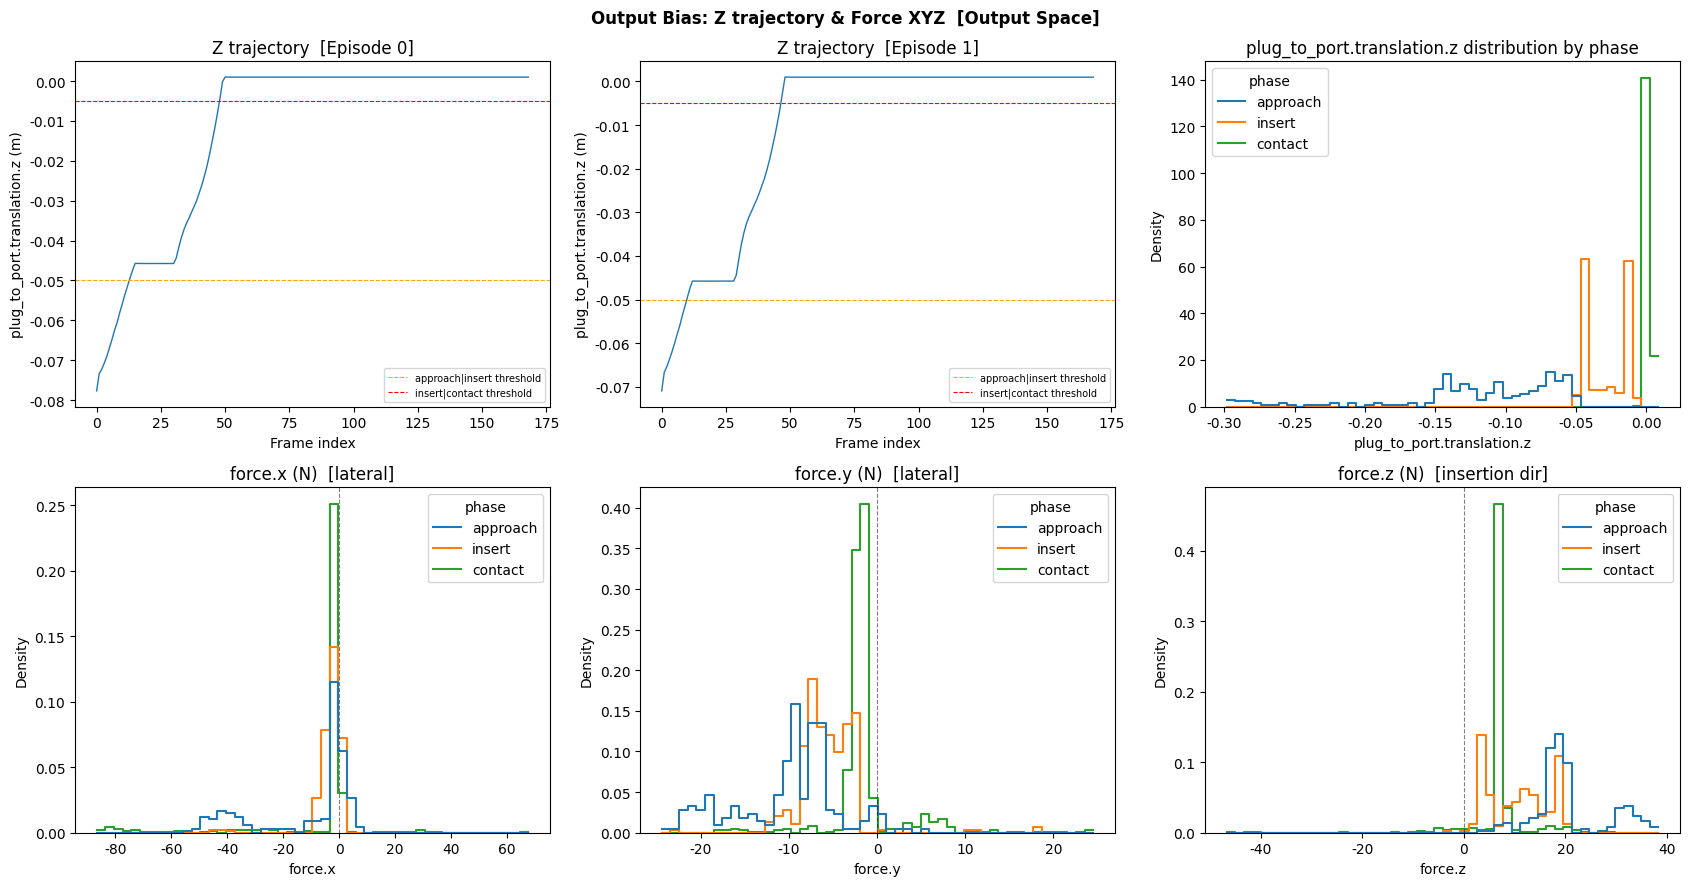

Force stats by phase:


force.x                                                              force.y                                                             force.z                   \
           count     mean      std      min      25%     50%     75%      max   count     mean     std      min      25%     50%     75%      max   count     mean     std   
phase                                                                                                                                                                        
approach   219.0 -11.2881  17.6677 -53.0142 -22.8127 -2.3423 -0.0415   8.5797   219.0 -10.0497  5.8323 -24.4430 -13.2254 -9.4222 -6.7586   4.9973   219.0  20.7293  7.1167   
contact    701.0  -6.1239  18.5220 -86.6472  -2.2045 -1.3028 -0.6488  67.6152   701.0  -1.2994  4.1619 -18.3409  -2.5085 -1.7509 -1.2146  24.5458   701.0   6.9376  5.4315   
insert     297.0  -2.9853   5.9177 -46.3516  -5.8275 -0.7693 -0.3337   1.4122   297.0  -5.5209  3.5064 -22.7659  -7.5072 -5.7219 -3.3873  18.0432   297.0  10.6265  6.0418   

                                                       
              min      25%      50%      75%      max  
phase                                                  
approach   2.8283  16.9541  19.3201  20.2219  38.2894  
contact  -46.6629   6.6439   7.1464   7.4960  28.6440  
insert    -4.1708   4.2786  10.9059  16.9295  19.7846

  std(force.x) / std(force.z) = 0.979  [HIGH lateral force — alignment issues likely]
  std(force.y) / std(force.z) = 0.580  [HIGH lateral force — alignment issues likely]


In [11]:
# ── 2-2: plug_to_port.translation.z trajectory & Force XYZ distribution ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# (row 0) tz 궤적: episode 0, 1 / 전체 위상별 분포
for ep, ax in zip([0, 1], axes[0, :2]):
    sg = steps_df[steps_df['episode_index'] == ep]
    ax.plot(sg['frame_index'], sg['plug_to_port.translation.z'], lw=1.0)
    ax.axhline(-0.05,  color='orange', lw=0.8, ls='--', label='approach|insert threshold')
    ax.axhline(-0.005, color='red',    lw=0.8, ls='--', label='insert|contact threshold')
    ax.set_xlabel('Frame index'); ax.set_ylabel('plug_to_port.translation.z (m)')
    ax.set_title(f'Z trajectory  [Episode {ep}]')
    ax.legend(fontsize=7)

sns.histplot(data=steps_df, x='plug_to_port.translation.z', hue='phase', bins=50,
             stat='density', common_norm=False, element='step',
             fill=False, ax=axes[0, 2])
axes[0, 2].set_title('plug_to_port.translation.z distribution by phase')

# (row 1) Force x / y / z by phase
for ax, col, label in zip(
    axes[1],
    ['force.x', 'force.y', 'force.z'],
    ['force.x (N)  [lateral]', 'force.y (N)  [lateral]', 'force.z (N)  [insertion dir]']
):
    sns.histplot(data=steps_df, x=col, hue='phase', bins=50,
                 stat='density', common_norm=False, element='step',
                 fill=False, ax=ax)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(label); ax.set_xlabel(col)

plt.suptitle('Output Bias: Z trajectory & Force XYZ  [Output Space]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Force stats by phase:')
display(steps_df.groupby('phase')[['force.x','force.y','force.z']].describe().round(4))

ins = steps_df[steps_df['phase'] == 'insert']
for col in ['force.x', 'force.y']:
    ratio = ins[col].std() / (ins['force.z'].std() + 1e-9)
    flag  = 'HIGH lateral force — alignment issues likely' if ratio > 0.5 else 'OK'
    print(f'  std({col}) / std(force.z) = {ratio:.3f}  [{flag}]')

## Section 3-1 — 이미지 샘플링 (분석 준비)

### 무엇을 보는가
AV1 코덱 영상에서 `ffmpeg` 를 사용해 균등 간격으로 N개 프레임을 배치 추출합니다.  
`img_df` 는 이후 3-2~5-2 의 모든 이미지 분석에서 입력으로 사용됩니다.

### 어떻게 판단하는가
- `Sampled image records` 수가 예상값 (`episodes × views × N_PER_EP`) 인지 확인


In [ ]:
# ── 3-1: Image sampling ───────────────────────────────────────────────────────
N_PER_EP = 30  # frames to sample per episode

def video_path(view_key: str, episode_idx: int) -> Path:
    ep = steps_df[steps_df['episode_index'] == episode_idx].iloc[0]
    # chunk = episode_idx // info['chunks_size']
    chunk = 0
    return DATA_ROOT / 'videos' / view_key / f'chunk-{chunk:03d}' / f'file-{episode_idx:03d}.mp4'

def batch_extract_frames(video: Path, frame_indices: list) -> dict:
    """Extract frames at given indices using ffmpeg; returns {idx: rgb_array}."""
    if not frame_indices: return {}
    select_expr = '+'.join([f'eq(n\\,{i})' for i in frame_indices])
    cmd = [
        'ffmpeg', '-y', '-i', str(video),
        '-vf', f'select={select_expr}',
        '-vsync', 'vfr',
        '-f', 'rawvideo', '-pix_fmt', 'rgb24', '-'
    ]
    res = subprocess.run(cmd, capture_output=True)
    if res.returncode != 0 or not res.stdout:
        return {}
    n_bytes = RESIZE_H * RESIZE_W * 3
    n_got   = len(res.stdout) // n_bytes
    arr     = np.frombuffer(res.stdout, dtype=np.uint8).reshape(n_got, RESIZE_H, RESIZE_W, 3)
    return {idx: arr[i] for i, idx in enumerate(frame_indices[:n_got])}

# build image-level metadata table (no actual pixels yet, just indices)
img_rows = []
for ep_idx, ep_df in steps_df.groupby('episode_index'):
    sampled_fi = np.linspace(0, len(ep_df)-1, N_PER_EP, dtype=int)
    for fi in sampled_fi:
        row = ep_df.iloc[fi]
        for view in VIEWS:
            img_rows.append({
                'episode_index': ep_idx,
                'frame_index':   int(row['frame_index']),
                'view':          view,
                'phase':         row['phase'],
                'plug_to_port.translation.z': row['plug_to_port.translation.z'],
            })

img_df = pd.DataFrame(img_rows)
display(img_df.head(6))
print(f'Sampled image records: {len(img_df):,}')

In [ ]:
# ── 3-1b: 실제 픽셀 로드 (numpy 배열 캐시) ────────────────────────────────────
FRAME_CACHE = {}  # (episode_index, view, frame_index) → rgb (H,W,3)

for (ep_idx, view), grp in tqdm(
    img_df.groupby(['episode_index', 'view']), desc='Loading frames'
):
    vkey = f'observation.images.{view}_camera'
    vpath = video_path(vkey, ep_idx)
    frame_indices = sorted(grp['frame_index'].unique().tolist())
    frames = batch_extract_frames(vpath, frame_indices)
    for fi, arr in frames.items():
        FRAME_CACHE[(ep_idx, view, fi)] = arr

print(f'Cached frames: {len(FRAME_CACHE)}')

def get_gray(ep, view, fi):
    rgb = FRAME_CACHE.get((ep, view, fi))
    if rgb is None: return None
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)

def get_rgb(ep, view, fi):
    return FRAME_CACHE.get((ep, view, fi))

## Section 3-2 — 샘플 프레임 시각화 (3-view 확인)

각 에피소드의 첫 샘플 프레임을 left / center / right 순서로 나란히 확인합니다.

In [ ]:
# ── 3-2: Sample frame visualisation ──────────────────────────────────────────
n_eps = steps_df['episode_index'].nunique()
fig, axes = plt.subplots(n_eps, 3, figsize=(12, 4*n_eps))
if n_eps == 1:
    axes = axes[np.newaxis, :]

for r, ep_idx in enumerate(sorted(steps_df['episode_index'].unique())):
    ep_grp = img_df[img_df['episode_index'] == ep_idx]
    fi0    = ep_grp['frame_index'].iloc[0]
    for c, view in enumerate(VIEWS):
        rgb = get_rgb(ep_idx, view, fi0)
        ax  = axes[r, c]
        if rgb is not None:
            ax.imshow(rgb)
            ax.set_title(f'ep{ep_idx} frame{fi0}  [{view}]', fontsize=9)
        else:
            ax.text(0.5, 0.5, 'no frame', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('Sample Frames — 3-view confirmation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4-1 — 픽셀 분산 히트맵 (Input Spatial Bias)

### 무엇을 보는가
여러 프레임에 걸쳐 각 픽셀 위치의 분산을 계산합니다.  
분산이 높은 픽셀 = 로봇/플러그가 자주 지나가는 위치.  
분산이 낮은 픽셀 = 항상 같은 배경 → 인코더가 무시해도 되는 영역.

### 어떻게 판단하는가
**분산 에너지 집중도 (spatial_conc)**: 분산 에너지의 50%를 담당하는 픽셀 비율  
- < 0.15 → BIASED (특정 영역에 과도 집중)  
- 0.15–0.30 → caution  
- > 0.30 → OK


In [ ]:
# ── 4-1: Pixel variance heatmap — where does motion concentrate? ─────────────
var_maps = {}  # (view, episode) → variance map

for (ep_idx, view), grp in tqdm(
    img_df.groupby(['episode_index', 'view']), desc='Variance maps'
):
    frames = [get_gray(ep_idx, view, fi) for fi in grp['frame_index'] if get_gray(ep_idx, view, fi) is not None]
    if len(frames) > 1:
        var_maps[(view, ep_idx)] = np.stack(frames).var(axis=0)

n_eps = steps_df['episode_index'].nunique()
fig, axes = plt.subplots(n_eps, 3, figsize=(15, 5*n_eps))
if n_eps == 1: axes = axes[np.newaxis, :]

for row_i, ep_idx in enumerate(sorted(steps_df['episode_index'].unique())):
    for col_i, view in enumerate(VIEWS):
        ax = axes[row_i][col_i]
        vm = var_maps.get((view, ep_idx))
        if vm is None: continue
        im = ax.imshow(vm)
        plt.colorbar(im, ax=ax, fraction=0.046)
        hy, hx = np.unravel_index(vm.argmax(), vm.shape)
        ax.scatter([hx], [hy], c='cyan', s=60, marker='+', linewidths=2)
        ax.set_title(f'ep{ep_idx} — {view}  peak=({hx},{hy})')
        ax.axis('off')

plt.suptitle('Pixel Variance Heatmap  [Input Spatial Bias]', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

def spatial_conc(vm, thr=0.5):
    flat = np.sort(vm.flatten())[::-1]
    cs = np.cumsum(flat)
    n  = np.searchsorted(cs, cs[-1]*thr) + 1
    return n / flat.size

print('\nSpatial concentration (fraction of pixels holding 50% variance energy):')
print(f'  {"view":8s} {"ep":4s}  value   note')
for (view, ep_idx), vm in sorted(var_maps.items()):
    c    = spatial_conc(vm)
    flag = 'BIASED' if c < 0.15 else ('OK' if c > 0.30 else 'caution')
    print(f'  {view:8s} ep{ep_idx}  {c:.3f}   {flag}')

## Section 4-2 — CV 특징 함수 정의

이후 4-3~4-5에서 사용되는 이미지 특징 추출 함수들을 정의합니다.

| 함수 | 측정 대상 | 의미 |
|------|----------|------|
| `fft_high_ratio` | 고주파 에너지 비율 | 높을수록 엣지/텍스처 풍부 |
| `hue_entropy` | 색상 다양성 (엔트로피) | 높을수록 다양한 색상 |
| `fg_bbox` | 전경 객체 중심 | 인코더 attention 영역 추정 |


In [ ]:
# ── 4-2: CV feature functions ─────────────────────────────────────────────────
def fft_high_ratio(gray, frac=0.18):
    f   = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
    mag = np.abs(f)
    h, w = gray.shape
    cy, cx = h//2, w//2
    ry, rx = int(h*frac/2), int(w*frac/2)
    mask = np.zeros_like(gray, dtype=bool)
    mask[cy-ry:cy+ry+1, cx-rx:cx+rx+1] = True
    return float(mag[~mask].sum() / (mag.sum()+1e-6))

def hue_entropy(hsv, bins=36):
    sat, hue = hsv[:,:,1], hsv[:,:,0]
    valid = sat > 25
    if valid.sum() < 64: return np.nan
    hist, _ = np.histogram(hue[valid], bins=bins, range=(0,180), density=True)
    hist = hist[hist>0]
    return float(-(hist * np.log(hist+1e-9)).sum())

def fg_bbox(rgb):
    lab   = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    h, w  = lab.shape[:2]
    border = np.concatenate([
        lab[:16].reshape(-1,3), lab[-16:].reshape(-1,3),
        lab[:,:16].reshape(-1,3), lab[:,-16:].reshape(-1,3)
    ])
    dist  = np.linalg.norm(lab.astype(np.float32) - np.median(border,0).astype(np.float32), axis=2)
    mask  = ((dist > np.percentile(dist,82))*255).astype(np.uint8)
    mask  = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((5,5),np.uint8))
    mask  = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    ic    = np.array([w/2, h/2])
    best, bscore = None, None
    for i in range(1, n):
        a  = stats[i, cv2.CC_STAT_AREA]
        if a < 80: continue
        cx = stats[i, cv2.CC_STAT_LEFT] + stats[i, cv2.CC_STAT_WIDTH]/2
        cy = stats[i, cv2.CC_STAT_TOP]  + stats[i, cv2.CC_STAT_HEIGHT]/2
        s  = a - 3000*np.linalg.norm((np.array([cx,cy])-ic)/np.array([w,h]))
        if bscore is None or s > bscore: bscore, best = s, i
    if best is None: return np.nan, np.nan
    s = stats[best]
    return (s[cv2.CC_STAT_LEFT]+s[cv2.CC_STAT_WIDTH]/2)/w, \
           (s[cv2.CC_STAT_TOP] +s[cv2.CC_STAT_HEIGHT]/2)/h

print('CV functions ready')

## Section 4-3 — CV 특징 추출 (view × phase)

In [ ]:
# ── 4-3: CV feature extraction ────────────────────────────────────────────────
cv_rows = []

for (ep_idx, view, phase), grp in tqdm(
    img_df.groupby(['episode_index', 'view', 'phase']), desc='CV features'
):
    for _, row in grp.iterrows():
        rgb = get_rgb(ep_idx, view, row['frame_index'])
        if rgb is None: continue
        try:
            gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            gf   = gray.astype(np.float32)
            hsv  = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
            val, sat = hsv[:,:,2], hsv[:,:,1]

            lap  = float(cv2.Laplacian(gf, cv2.CV_32F).var())
            ns   = float((gf - cv2.GaussianBlur(gf,(0,0),1.0)).std())
            fft  = fft_high_ratio(gray)
            edge = float((cv2.Canny(gray,40,120)>0).mean())
            bri  = float(val.mean()/255)
            sat_m= float(sat.mean()/255)
            hent = hue_entropy(hsv)
            fx, fy = fg_bbox(rgb)

            cv_rows.append({
                'episode_index': ep_idx,
                'frame_index':   row['frame_index'],
                'phase': phase, 'view': view,
                'laplacian_var': lap, 'noise_std': ns,
                'fft_high': fft, 'edge_density': edge,
                'brightness': bri, 'saturation': sat_m, 'hue_entropy': hent,
                'fg_cx': fx, 'fg_cy': fy,
            })
        except Exception:
            continue

cv_df = pd.DataFrame(cv_rows)
print(f'CV records: {len(cv_df):,}')
display(cv_df.head(5))

## Section 4-4 — 노이즈 / 텍스처 / 주파수 (Input Feature Bias)

### 무엇을 보는가
laplacian_var (선명도), noise_std (고주파 노이즈), fft_high_ratio (주파수 분포),  
edge_density (엣지 밀도) 를 뷰 × phase 조합으로 boxplot 비교합니다.

### 어떻게 판단하는가
- 뷰간 차이가 크면 → 뷰 별 독립 인코더 필요
- phase 간 차이가 크면 → 위상 조건부 augmentation 고려


In [ ]:
# ── 4-4: Noise / Texture / Frequency (view x phase) ──────────────────────────
cv_df['view_ep'] = cv_df['view'] + '/ep' + cv_df['episode_index'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, ['laplacian_var','noise_std','fft_high','edge_density']):
    sns.boxplot(data=cv_df, x='view', y=col, hue='phase', ax=ax, showfliers=False)
    ax.set_title(col); ax.set_xlabel('')

plt.suptitle('Noise / Texture / Frequency  [Input Feature Bias]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4-5 — HSV 스칼라 특징 (Input Appearance Bias)

### 무엇을 보는가
brightness (명도), saturation (채도), hue_entropy (색상 다양성) 를 뷰 × episode 로 비교합니다.  
phase 간 brightness 분포 차이도 히스토그램으로 시각화합니다.


In [ ]:
# ── 4-5: HSV scalar features (view x episode) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['brightness','saturation','hue_entropy']):
    sns.boxplot(data=cv_df, x='view', y=col,
                hue='episode_index', ax=ax, showfliers=False)
    ax.set_title(col)

plt.suptitle('HSV Scalar Features  [Input Appearance Bias]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# brightness by phase
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, view in zip(axes, VIEWS):
    sns.histplot(data=cv_df[cv_df['view']==view], x='brightness', hue='phase',
                 bins=25, stat='density', common_norm=False,
                 element='step', fill=False, ax=ax)
    ax.set_title(f'{view}  brightness by phase')

plt.suptitle('Brightness Distribution: phase-domain shift  [Appearance Bias]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5-1 — Cross-view 픽셀 차이 (View Diversity)

### 무엇을 보는가
동일 시점(same frame)에서 left / center / right 뷰 pair별 픽셀 절대 차이를  
히트맵으로 시각화합니다.

### 어떻게 판단하는가
| mean diff | 의미 | 인코더 설계 시사점 |
|-----------|------|-------------------|
| < 10 | 뷰 거의 동일 | shared encoder 가능 |
| 10–30 | 보통 차이 | shared + view-specific head |
| > 30 | 큰 차이 | 독립 인코더 권장 |


In [ ]:
# ── 5-1: Cross-view pixel difference (insert phase) ──────────────────────────
diff_lc = np.zeros((RESIZE_H, RESIZE_W))
diff_lr = np.zeros((RESIZE_H, RESIZE_W))
n_pairs = 0

insert_frames = img_df[img_df['phase'] == 'insert']

for (ep_idx, fi), grp in tqdm(
    insert_frames.groupby(['episode_index', 'frame_index']), desc='Pixel diff'
):
    lg = get_gray(ep_idx, 'left',   fi)
    cg = get_gray(ep_idx, 'center', fi)
    rg = get_gray(ep_idx, 'right',  fi)
    if lg is None or cg is None or rg is None: continue
    diff_lc += np.abs(lg - cg)
    diff_lr += np.abs(lg - rg)
    n_pairs += 1

if n_pairs > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, dm, title in [
        (axes[0], diff_lc/n_pairs, 'left vs center'),
        (axes[1], diff_lr/n_pairs, 'left vs right')
    ]:
        im = ax.imshow(dm)
        plt.colorbar(im, ax=ax)
        ax.set_title(f'{title}  mean diff = {dm.mean():.2f}')
        ax.axis('off')
    plt.suptitle('Cross-view Pixel Difference  [View Diversity]',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Frame pairs used: {n_pairs}')
else:
    print('No insert-phase frames to compare.')

## Section 5-2 — Cross-view 특징 상관관계 (Shared Encoder Validity)

### 무엇을 보는가
같은 프레임에서 left / center / right 의 brightness, laplacian, fft, edge 값을  
pairwise Pearson r 로 비교합니다. 상관이 높으면 → shared encoder 가정이 성립합니다.

### 어떻게 판단하는가
- r > 0.8 → shared encoder OK
- r < 0.5 → 뷰 별 독립 인코더 검토


In [ ]:
# ── 5-2: Cross-view feature correlation ───────────────────────────────────────
cv_wide_rows = []

for (ep_idx, fi), grp in tqdm(
    cv_df.groupby(['episode_index', 'frame_index']), desc='Cross-view corr'
):
    if grp['view'].nunique() < 3: continue
    row_dict = {'episode_index': ep_idx, 'frame_index': fi}
    for _, vr in grp.iterrows():
        for feat in ['brightness','laplacian_var','fft_high','edge_density']:
            row_dict[f"{vr['view']}_{feat}"] = vr[feat]
    cv_wide_rows.append(row_dict)

wide_df = pd.DataFrame(cv_wide_rows)

feat_names = ['brightness','laplacian_var','fft_high','edge_density']
feat_short  = ['brightness','laplacian','fft','edge']
fig, axes = plt.subplots(1, len(feat_names), figsize=(18, 4))
corr_out = {}

for ax, feat, fs in zip(axes, feat_names, feat_short):
    lc = f'left_{feat}'; cc = f'center_{feat}'; rc = f'right_{feat}'
    if not all(c in wide_df for c in [lc, cc, rc]): continue
    r_lc = wide_df[lc].corr(wide_df[cc])
    r_lr = wide_df[lc].corr(wide_df[rc])
    r_cr = wide_df[cc].corr(wide_df[rc])
    corr_out[fs] = {'L-C': r_lc, 'L-R': r_lr, 'C-R': r_cr}
    ax.scatter(wide_df[lc], wide_df[cc], alpha=0.5, s=10, label=f'L-C r={r_lc:.2f}')
    ax.scatter(wide_df[cc], wide_df[rc], alpha=0.5, s=10, marker='s', label=f'C-R r={r_cr:.2f}')
    ax.set_title(fs); ax.legend(fontsize=7)

plt.suptitle('Cross-view Feature Correlation  [Shared Encoder Validity]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPearson r (r > 0.8 → shared encoder OK):')
if corr_out:
    display(pd.DataFrame(corr_out).T.round(3))

## Section 6 — Temporal Redundancy (프레임 간 시간적 중복성)

### 무엇을 보는가
연속된 두 프레임이 얼마나 다른가를 시간 축으로 측정합니다.  
MAD (Mean Absolute Difference) 와 SSIM 을 프레임 단위로 계산합니다.

### 어떻게 판단하는가
| 지표 | 임계값 | 의미 |
|------|--------|------|
| SSIM > 0.95 비율 > 30% | 심각한 중복 | temporal stride ≥ 3 권장 |
| MAD < 1.5 | 거의 같은 프레임 | stride 증가 고려 |


In [ ]:
# ── 6: Temporal Redundancy ────────────────────────────────────────────────────
from skimage.metrics import structural_similarity as ssim_fn

RESIZE_TEMP_H = 128
RESIZE_TEMP_W = 144
SSIM_THRESHOLD = 0.95
MAD_LOW_THRESHOLD = 1.5

temp_rows = []

for ep_idx, ep_df in tqdm(steps_df.groupby('episode_index'), desc='Temporal redundancy'):
    vpath = video_path('observation.images.center_camera', ep_idx)
    all_fi = ep_df['frame_index'].tolist()
    select_expr = '+'.join([f'eq(n\\,{i})' for i in all_fi])
    cmd = [
        'ffmpeg', '-y', '-i', str(vpath),
        '-vf', f'select={select_expr}',
        '-vsync', 'vfr', '-f', 'rawvideo', '-pix_fmt', 'gray', '-'
    ]
    res = subprocess.run(cmd, capture_output=True)
    if res.returncode != 0 or not res.stdout:
        continue

    n_bytes = RESIZE_H * RESIZE_W
    n_got   = len(res.stdout) // n_bytes
    frames_all = np.frombuffer(res.stdout, dtype=np.uint8).reshape(n_got, RESIZE_H, RESIZE_W)

    prev = None
    for i, (_, row) in enumerate(ep_df.iterrows()):
        if i >= n_got: break
        img_full = frames_all[i]
        img = cv2.resize(img_full, (RESIZE_TEMP_W, RESIZE_TEMP_H)).astype(np.float32)
        if prev is not None:
            mad  = float(np.abs(img - prev).mean())
            ssim = float(ssim_fn(img, prev, data_range=255))
            temp_rows.append({
                'episode_index': ep_idx,
                'frame_index':   int(row['frame_index']),
                'phase':         row['phase'],
                'mad':  mad,
                'ssim': ssim,
            })
        prev = img

temp_df = pd.DataFrame(temp_rows)
print(f'Consecutive frame pairs analyzed: {len(temp_df):,}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=temp_df, x='mad', hue='phase', bins=40,
             stat='density', common_norm=False, element='step', fill=False, ax=axes[0])
axes[0].axvline(MAD_LOW_THRESHOLD, color='red', ls='--', lw=1,
                label=f'low-change threshold ({MAD_LOW_THRESHOLD})')
axes[0].set_title('MAD distribution by phase'); axes[0].legend()

sns.histplot(data=temp_df, x='ssim', hue='phase', bins=40,
             stat='density', common_norm=False, element='step', fill=False, ax=axes[1])
axes[1].axvline(SSIM_THRESHOLD, color='red', ls='--', lw=1,
                label=f'near-identical threshold ({SSIM_THRESHOLD})')
axes[1].set_title('SSIM distribution by phase'); axes[1].legend()

for ep_idx, sg in temp_df.groupby('episode_index'):
    axes[2].plot(sg['frame_index'], sg['mad'], alpha=0.6, lw=0.8, label=f'ep{ep_idx}')
axes[2].axhline(MAD_LOW_THRESHOLD, color='red', ls='--', lw=1)
axes[2].set_title('MAD over frames (per episode)')
axes[2].set_xlabel('Frame index'); axes[2].set_ylabel('MAD')
axes[2].legend()

plt.suptitle('Section 6 — Temporal Redundancy  [Frame-to-Frame Change]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

high_ssim_ratio = (temp_df['ssim'] > SSIM_THRESHOLD).mean()
print(f'\nFraction of pairs with SSIM > {SSIM_THRESHOLD}: {high_ssim_ratio:.2%}')
print(f'  → {"REDUNDANT — temporal stride >= 3 recommended" if high_ssim_ratio > 0.30 else "OK — stride 1~2 sufficient"}')
print('\nMAD stats by phase:')
display(temp_df.groupby('phase')['mad'].describe().round(3))

## Section 7 — PCA / t-SNE Separability (시각적 분리 가능성)

### 무엇을 보는가
이미지 픽셀을 PCA 로 차원 축소한 뒤 t-SNE 로 2D 시각화합니다.  
**episode** 와 **phase** 라벨을 색으로 표시하여 시각적 분리 가능성을 확인합니다.

### 어떻게 판단하는가
- t-SNE 클러스터가 라벨별 분리됨 → 인코더가 해당 개념을 학습 가능
- logistic regression Δacc > 0.10 → 선형 분리 가능


In [ ]:
# ── 7: PCA / t-SNE separability ───────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

RESIZE_PCA_H, RESIZE_PCA_W = 64, 72
N_PCA_COMPONENTS = 30

pca_imgs, pca_meta = [], []

for ep_idx in steps_df['episode_index'].unique():
    vpath = video_path('observation.images.center_camera', ep_idx)
    ep_df = steps_df[steps_df['episode_index'] == ep_idx]
    all_fi = ep_df['frame_index'].tolist()

    select_expr = '+'.join([f'eq(n\\,{i})' for i in all_fi])
    cmd = [
        'ffmpeg', '-y', '-i', str(vpath),
        '-vf', f'select={select_expr}',
        '-vsync', 'vfr', '-f', 'rawvideo', '-pix_fmt', 'gray', '-'
    ]
    res = subprocess.run(cmd, capture_output=True)
    if res.returncode != 0 or not res.stdout: continue

    n_bytes = RESIZE_H * RESIZE_W
    n_got   = len(res.stdout) // n_bytes
    frames_all = np.frombuffer(res.stdout, dtype=np.uint8).reshape(n_got, RESIZE_H, RESIZE_W)

    for i, (_, row) in enumerate(ep_df.iterrows()):
        if i >= n_got: break
        img = cv2.resize(frames_all[i], (RESIZE_PCA_W, RESIZE_PCA_H)).astype(np.float32) / 255.0
        pca_imgs.append(img.flatten())
        pca_meta.append({'episode_index': ep_idx, 'phase': row['phase']})

X      = np.array(pca_imgs)
meta_df = pd.DataFrame(pca_meta)
print(f'Image matrix: {X.shape}')

n_comp = min(N_PCA_COMPONENTS, X.shape[0]-1)
pca    = PCA(n_components=n_comp, random_state=42)
X_pca  = pca.fit_transform(X)

tsne  = TSNE(n_components=2, perplexity=min(30, len(X_pca)//4),
             random_state=42, max_iter=800, verbose=0)
X_2d  = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA explained variance
ev = np.cumsum(pca.explained_variance_ratio_) * 100
axes[0].plot(range(1, len(ev)+1), ev, marker='o', ms=3)
axes[0].axhline(70, color='red',    ls='--', lw=1, label='70%')
axes[0].axhline(90, color='orange', ls='--', lw=1, label='90%')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumul. explained var (%)')
axes[0].set_title('PCA Explained Variance'); axes[0].legend(fontsize=8)

# t-SNE by episode
palette_ep = {0: '#2196F3', 1: '#FF5722'}
for ep_idx, color in palette_ep.items():
    mask = meta_df['episode_index'] == ep_idx
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.5, s=8, label=f'ep{ep_idx}')
axes[1].set_title('t-SNE  by episode'); axes[1].legend(markerscale=3); axes[1].axis('off')

# t-SNE by phase
palette_ph = {'approach': '#4CAF50', 'insert': '#9C27B0', 'contact': '#FF9800'}
for phase, color in palette_ph.items():
    mask = meta_df['phase'] == phase
    if mask.sum() == 0: continue
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.5, s=8, label=phase)
axes[2].set_title('t-SNE  by phase'); axes[2].legend(markerscale=3); axes[2].axis('off')

plt.suptitle('PCA / t-SNE Separability  [Encoder Learnability]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Linear separability
for label_col, label_name in [('episode_index','Episode'), ('phase','Phase')]:
    y = meta_df[label_col].values
    score = cross_val_score(
        LogisticRegression(max_iter=300, random_state=42),
        X_pca, y, cv=min(5, len(np.unique(y))*2), scoring='accuracy'
    ).mean()
    baseline = pd.Series(y).value_counts(normalize=True).max()
    delta    = score - baseline
    flag     = 'SEPARABLE' if delta>0.10 else ('marginal' if delta>0.03 else 'NOT separable')
    print(f'[{label_name:10s}] acc={score:.3f}  baseline={baseline:.3f}  Δ={delta:+.3f}  [{flag}]')

## Section 8 — Gripper Offset 편차 분석

### 배경
`gripper_offset.x/y/z` = 그리퍼에 장착된 플러그의 offset (로봇 프레임 내 미터 단위).  
에피소드 간 deviation 분포가 좁으면 → 다양한 조건 테스트를 위한 augmentation 이 필요합니다.

### 어떻게 판단하는가
| 위치 편차 std | 의미 |
|--------------|------|
| > 2 mm | OK — 사양 범위 커버 |
| 1–2 mm | caution |
| < 1 mm | AUGMENT NEEDED — ±2 mm perturbation 추가 |


In [ ]:
# ── 8: Gripper Offset deviation ───────────────────────────────────────────────
grip_cols = ['gripper_offset.x', 'gripper_offset.y', 'gripper_offset.z']

# per-episode first frame offset
ep_offsets = []
for ep_idx, grp in steps_df.groupby('episode_index'):
    row0 = grp.sort_values('frame_index').iloc[0]
    ep_offsets.append({
        'episode_index': ep_idx,
        'grip_x_mm': row0['gripper_offset.x']*1000,
        'grip_y_mm': row0['gripper_offset.y']*1000,
        'grip_z_mm': row0['gripper_offset.z']*1000,
    })
ep_off_df = pd.DataFrame(ep_offsets)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['grip_x_mm','grip_y_mm','grip_z_mm']):
    sns.boxplot(data=steps_df.assign(
        **{c: steps_df[c.replace('grip_','gripper_offset.').replace('_mm','')]*1000
           for c in ['grip_x_mm','grip_y_mm','grip_z_mm']
           }
    ).rename(columns={'gripper_offset.x':'grip_x_mm','gripper_offset.y':'grip_y_mm','gripper_offset.z':'grip_z_mm'}),
        x='episode_index', y=col, ax=ax, showfliers=True)
    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.set_title(col)

plt.suptitle('Gripper Offset Distribution  [Episode Comparison]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# trajectory over frame
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(
    axes, grip_cols,
    ['gripper_offset.x (m)', 'gripper_offset.y (m)', 'gripper_offset.z (m)']
):
    for ep_idx, grp in steps_df.groupby('episode_index'):
        ax.plot(grp['frame_index'], grp[col], lw=1.0, alpha=0.8, label=f'ep{ep_idx}')
    ax.set_xlabel('Frame'); ax.set_ylabel(label)
    ax.set_title(f'{label} trajectory')
    ax.legend(fontsize=8)

plt.suptitle('Gripper Offset Trajectory  [Robustness Indicator]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Gripper Offset Summary ===')
for col in grip_cols:
    std_mm = steps_df[col].std() * 1000
    flag   = 'OK' if std_mm > 2 else ('caution' if std_mm > 1 else 'AUGMENT NEEDED')
    print(f'  {col:25s}  std={std_mm:.4f} mm  [{flag}]')

## Section 9 — Scenario Params 분포 분석

### 무엇을 보는가
`observation.scenario_params` 11개 피처를 시각화합니다.  
보드 위치 (`board_x/y/yaw`), NIC/SC 파라미터의 분포를 에피소드 간 비교합니다.  
연속 파라미터에 대해 **Kolmogorov-Smirnov (KS) 검정**으로 균등분포 여부를 판단합니다.

### 어떻게 판단하는가
- 모든 값이 동일한 피처 → 편향 위험 (단일 조건에서만 학습)
- 에피소드 간 변동이 있는 피처 → 인코더가 조건 변화에 견고해야 함

| KS p-value | 의미 |
|------------|------|
| > 0.05 | 균등분포 기각 불가 (OK) |
| ≤ 0.05 | 균등분포 기각 → 편향 의심 |


In [ ]:
# ── 9: Scenario Params 분포 + 균등분포 KS 검정 ─────────────────────────────
import math
from scipy import stats

scenario_cols = [
    'trial_type', 'rail_idx', 'board_x', 'board_y', 'board_yaw',
    'gripper_offset_x', 'gripper_offset_y', 'gripper_offset_z',
    'nic_translation', 'nic_yaw', 'sc_translation',
]

# 에피소드별 첫 프레임으로 파라미터 추출
ep_sc = steps_df.groupby('episode_index')[scenario_cols].first().reset_index(drop=True)
print('Scenario params per episode (first frame):')
display(ep_sc.T.style.format('{:.4f}'))

# ── 이산 파라미터 bar chart ───────────────────────────────────────────────────
discrete_cols = ['trial_type', 'rail_idx']
fig, axes = plt.subplots(1, len(discrete_cols), figsize=(8, 4))
for ax, col in zip(axes, discrete_cols):
    cnts = ep_sc[col].value_counts().sort_index()
    ax.bar(cnts.index.astype(str), cnts.values, color='steelblue', edgecolor='black')
    ax.set_title(col); ax.set_xlabel('value'); ax.set_ylabel('episode count')
    for i, v in enumerate(cnts.values):
        ax.text(i, v + 0.05, str(v), ha='center', fontsize=10)
plt.suptitle('Discrete Scenario Params (per episode)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 연속 파라미터: 히스토그램 + KS test ──────────────────────────────────────
continuous_cols = [c for c in scenario_cols if c not in discrete_cols]

# NIC/SC 분리: board_x/y는 trial_type에 따라 범위 다름
LIMITS = {
    'board_yaw':        (0.0, math.pi),
    'nic_translation':  (-0.0215, 0.0234),
    'nic_yaw':          (-math.radians(10), math.radians(10)),
    'sc_translation':   (-0.06, 0.055),
    'gripper_offset_x': (-0.002, 0.002),
    'gripper_offset_y': (0.015385 - 0.002, 0.015385 + 0.002),
    'gripper_offset_z': (0.04045 - 0.002, 0.04245 + 0.002),
    'board_x':          (0.13, 0.19),   # NIC: 0.13-0.17 / SC: 0.15-0.19 → 전체 union
    'board_y':          (-0.25, 0.05),  # NIC: -0.25~-0.15 / SC: -0.05~0.05 → union
}

n = len(continuous_cols)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flat

ks_results = []
for ax, col in zip(axes, continuous_cols):
    vals = ep_sc[col].dropna().values
    if len(vals) < 3:
        ax.set_title(f'{col}\n(데이터 부족)'); continue

    lo, hi = LIMITS.get(col, (vals.min(), vals.max()))
    in_range = vals[(vals >= lo) & (vals <= hi)]

    # 균등분포 KS 검정
    if len(in_range) >= 3 and (hi - lo) > 1e-9:
        ks_stat, ks_p = stats.kstest(
            in_range, lambda v: stats.uniform.cdf(v, loc=lo, scale=hi - lo)
        )
        verdict = '✓ 균등' if ks_p > 0.05 else '✗ 비균등'
    else:
        ks_stat, ks_p = float('nan'), float('nan')
        verdict = '–'

    ks_results.append({'param': col, 'n': len(vals), 'ks_stat': ks_stat,
                       'p_value': ks_p, 'verdict': verdict,
                       'range_used': f'[{lo:.4f}, {hi:.4f}]'})

    ax.hist(vals, bins=max(5, len(vals) // 2), edgecolor='black',
            color='steelblue', alpha=0.8, density=True)
    # 이론 균등분포 선
    x_line = np.linspace(lo, hi, 200)
    ax.axhline(1.0 / (hi - lo), color='red', lw=1.5, linestyle='--', label='Uniform pdf')
    color = 'green' if ks_p > 0.05 else 'red'
    ax.set_title(f'{col}\np={ks_p:.3f}  {verdict}', color=color, fontsize=9)
    ax.set_xlabel('value'); ax.set_ylabel('density'); ax.legend(fontsize=7)

# 빈 subplot 숨기기
for ax in list(axes)[n:]:
    ax.set_visible(False)

plt.suptitle('Scenario Params — Uniform Distribution Check (per episode)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# KS 검정 결과 테이블
ks_df = pd.DataFrame(ks_results).set_index('param')
print('\n=== KS 검정 결과 (균등분포) ===')
display(ks_df.style.applymap(
    lambda v: 'color: green' if v == '✓ 균등' else ('color: red' if v == '✗ 비균등' else ''),
    subset=['verdict']
).format({'ks_stat': '{:.4f}', 'p_value': '{:.4f}'}, na_rep='–'))


## Section 9-2 — Insertion Success 분석

### 무엇을 보는가
`insertion_success` 는 에피소드 마지막 프레임에 기록된 삽입 성공 여부입니다.  
(`1` = 성공, `0` = 실패, `-1` = 데이터 없음 / 구버전 포맷)

### 어떻게 판단하는가
- 성공률이 너무 높으면 → 학습 데이터가 쉬운 조건에 편중될 위험
- 성공률이 너무 낮으면 → policy 문제 또는 시뮬레이션 이슈


In [ ]:
# ── 9-2: Insertion Success Rate ──────────────────────────────────────────────
# 에피소드별 최대값: 마지막 프레임만 1이 될 수 있으므로 max() = episode 성공 여부
ep_success = steps_df.groupby('episode_index')['insertion_success'].max().reset_index()
ep_success.columns = ['episode_index', 'success']

has_data = (ep_success['success'] >= 0).all()

if not has_data:
    print('[경고] insertion_success 데이터 없음 (구버전 포맷 또는 미수집). 분석 생략.')
else:
    n_total   = len(ep_success)
    n_success = (ep_success['success'] == 1).sum()
    n_failure = (ep_success['success'] == 0).sum()
    rate      = n_success / n_total * 100

    print('=' * 50)
    print(f'  총 에피소드     : {n_total}')
    print(f'  성공 (1)        : {n_success}  ({rate:.1f}%)')
    print(f'  실패 (0)        : {n_failure}  ({100 - rate:.1f}%)')
    print('=' * 50)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # 좌: 성공/실패 bar
    ax = axes[0]
    labels = ['Success (1)', 'Failure (0)']
    counts = [n_success, n_failure]
    bars = ax.bar(labels, counts, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{cnt}\n({cnt/n_total*100:.1f}%)', ha='center', fontsize=11)
    ax.set_title(f'Insertion Success / Failure\n(total={n_total} episodes)')
    ax.set_ylabel('episode count')
    ax.set_ylim(0, max(counts) * 1.3)

    # 우: 에피소드별 success scatter
    ax = axes[1]
    colors = ep_success['success'].map({1: '#2ecc71', 0: '#e74c3c'})
    ax.scatter(ep_success['episode_index'], ep_success['success'],
               c=colors, s=80, edgecolors='black', linewidths=0.5, zorder=3)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Failure', 'Success'])
    ax.set_xlabel('episode_index'); ax.set_title('Success per Episode')
    ax.grid(axis='x', alpha=0.3)
    ax.set_ylim(-0.5, 1.5)

    plt.suptitle('Insertion Success Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # trial_type별 성공률
    ep_trial = steps_df.groupby('episode_index').agg(
        trial_type=('trial_type', 'first'),
        success=('insertion_success', 'max')
    ).reset_index()
    trial_summary = ep_trial.groupby('trial_type')['success'].agg(
        total='count', successes='sum'
    )
    trial_summary['success_rate_%'] = (trial_summary['successes'] / trial_summary['total'] * 100).round(1)
    trial_summary.index = trial_summary.index.map({0.0: 'NIC (0)', 1.0: 'SC (1)'})
    print('\n=== Trial Type별 성공률 ===')
    display(trial_summary)


## Section 10 — Bias Summary (설계 결론)

### 무엇을 보는가
Section 1~9 에서 발견한 편향들을 정리하고,  
백본 인코더 학습 전 반드시 적용해야 할 조치를 우선순위 순으로 출력합니다.


In [ ]:
# ── 10: Bias Summary ──────────────────────────────────────────────────────────
phase_cnt = steps_df['phase'].value_counts()
ins       = steps_df[steps_df['phase'] == 'insert']

print('='*65)
print('  Bias Summary  (lerobot/master dataset)')
print('='*65)

print('\n[1] PHASE IMBALANCE  (inferred from plug_to_port.translation.z)')
for ph in ['approach', 'insert', 'contact']:
    c = phase_cnt.get(ph, 0)
    print(f'    {ph:10s}: {c:6d}  ({c/phase_cnt.sum()*100:.1f}%)')
if phase_cnt.get('approach',0) == 0:
    print('    → No approach frames detected: dataset may start from insert phase')
else:
    dom = phase_cnt.idxmax()
    print(f'    → Dominant phase: {dom} — consider oversampling minority phases')

print('\n[2] EPISODE COUNT')
print(f'    Total episodes: {steps_df["episode_index"].nunique()}')
print(f'    → Very limited diversity — cross-episode generalisation at risk')

print('\n[3] PLUG-TO-PORT XY ERROR  (output distribution)')
xe = ins['plug_to_port.translation.x'].mean()*1000
ye = ins['plug_to_port.translation.y'].mean()*1000
xs = ins['plug_to_port.translation.x'].std()*1000
ys = ins['plug_to_port.translation.y'].std()*1000
sym = 'BIASED' if abs(xe)>xs*0.3 or abs(ye)>ys*0.3 else 'symmetric'
print(f'    Insert: x_mean={xe:+.3f}mm (std={xs:.3f})  '
      f'y_mean={ye:+.3f}mm (std={ys:.3f})  [{sym}]')
print('    → Add Gaussian XY offset (sigma~5mm) at insert start for diverse error range')

print('\n[4] SPATIAL INPUT BIAS  (see variance heatmap)')
for (view, ep_idx), vm in sorted(var_maps.items()):
    c    = spatial_conc(vm)
    flag = 'BIASED' if c < 0.15 else ('OK' if c > 0.30 else 'caution')
    print(f'    ep{ep_idx} {view:8s}: {c:.3f}  [{flag}]')
print('    → RandomCrop / Affine augmentation if BIASED')

print('\n[5] TEMPORAL REDUNDANCY')
if len(temp_df) > 0:
    hr = (temp_df['ssim'] > SSIM_THRESHOLD).mean()
    print(f'    SSIM > {SSIM_THRESHOLD} ratio: {hr:.2%}  '
          f'[{"REDUNDANT" if hr>0.30 else "OK"}]')
    print(f'    → Temporal stride >= 3 recommended' if hr > 0.30 else
          f'    → Stride 1~2 sufficient')

print('\n[6] GRIPPER OFFSET')
for col in grip_cols:
    std_mm = steps_df[col].std() * 1000
    flag   = 'OK' if std_mm > 2 else ('caution' if std_mm > 1 else 'AUGMENT NEEDED')
    print(f'    {col:25s}  std={std_mm:.4f} mm  [{flag}]')

print('\n[7] RECOMMENDATIONS')
recs = [
    '1. Collect more episodes (>= 20) covering diverse rail/board configurations',
    '2. Add Gaussian XY offset (sigma~5mm) at insert start for diverse tip error',
    '3. For spatially biased views: RandomCrop + AffineTransform augmentation',
    '4. Apply temporal stride >= 3 if SSIM redundancy is high',
    '5. Include approach-phase frames if dataset starts from insert',
    '6. Verify gripper_offset range covers ±2mm spec; add perturbation if not',
]
for r in recs:
    print(f'   {r}')
print('='*65)